In [2]:
import sys
sys.path.insert(0, '..')
from rap_simulation import Rubidium87, HyperfineState, Transition
stretch_transition = Rubidium87.list_transitions()[1]
b_field = 8e-4  #tesla
atom = Rubidium87(B_field=b_field, transition=stretch_transition)

print(atom)
print(atom.transition)
print(atom.transition_frequency)

from rap_simulation.simulation import CompositePulse, SimulationParams
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


Rubidium87(name='Rb-87 (stretch (mF=1<->mF=2))')
stretch (mF=1<->mF=2): |F=1, mF=1⟩ → |F=2, mF=2⟩
6851482610.90429


[np.float64(0.0005564429249899585), np.float64(0.0012915893861012962), np.float64(0.002671316578136145), np.float64(0.005045074810823701), np.float64(0.008852057874723656), np.float64(0.014608813626054306), np.float64(0.022884995311931878), np.float64(0.03429741704657159), np.float64(0.04941343782904849), np.float64(0.0687444123940105), np.float64(0.0927083319272752), np.float64(0.1215096830504496), np.float64(0.15512904944037853), np.float64(0.1933174204698725), np.float64(0.23546326628107336), np.float64(0.2806499891763372), np.float64(0.32779416936978073), np.float64(0.3753445439448456), np.float64(0.421564412979484), np.float64(0.46461771671110175)]
[np.float64(0.003522588544200587), np.float64(0.003263906387456566), np.float64(0.002528508236062455), np.float64(0.0014816197560108533), np.float64(0.00046401296666449896), np.float64(4.3765353708962617e-07), np.float64(0.0007898270924328203), np.float64(0.0036777919155475914), np.float64(0.009611581089742716), np.float64(0.01957510846

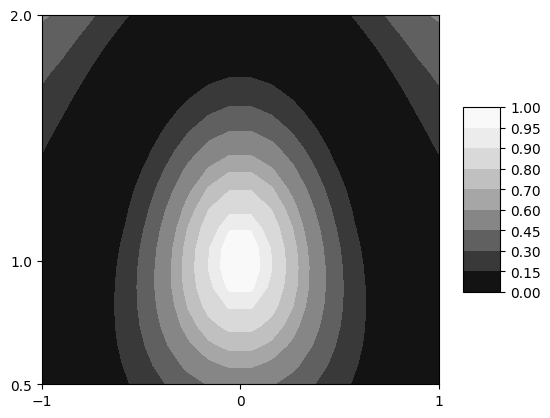

In [ ]:
#Exp Constant : 
omega=2*np.pi*10e3
points=5
d=np.linspace(-omega,omega,points)
amp=np.linspace(omega*0.5,omega*2,points)
pairs=[[a,b] for a in d for b in amp]


cst=[]
for x in d:
    row=[]
    for y in amp:
        omega_eff=y
        parameters = SimulationParams(
        T = 4e-4,
        dt = 0.1e-6,
        omega = omega,
        theta=np.pi,
        freq_span = 0,
        freq_span_center = x,
        omega_eff = omega_eff,
        sweep_time=np.pi/omega
        )
        rap = CompositePulse(atom, parameters)
        result = rap.run(pulse="constant", phase="constant")
        row.append(result.p1[-1])
    print(row)
    cst.append(row)

cst=np.array(cst)
abcs=np.linspace(-1,1,points)
ords=np.linspace(1/2,2,points)
x,y = np.meshgrid(abcs,ords,indexing='ij')

fig=plt.figure()

ax2=fig.add_subplot(111)
contour=ax2.contourf(x,y,cst,levels=[0, 0.15, 0.3,0.45,0.6,0.7,0.8,0.9,1],cmap='viridis')
fig.colorbar(contour,ax=ax2,shrink=0.5,aspect=5)
ax2.set_xticks([-1,0, 1])
ax2.set_yticks([0.5,1,2])
plt.show()



c:\Users\Sami\Project\RAP\venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[np.float64(0.0017432385410351932), np.float64(0.0024015743995743624), np.float64(0.0032385135804449895), np.float64(0.0042826720367334075), np.float64(0.005567908515273023), np.float64(0.0071404466775564345), np.float64(0.00901192631983353), np.float64(0.011265043074446777), np.float64(0.013969560007739587), np.float64(0.017160144591839344), np.float64(0.020954437449860114), np.float64(0.02542818510271703), np.float64(0.030724882228192026), np.float64(0.03700390666789591), np.float64(0.04440183807972375), np.float64(0.05314278025340456), np.float64(0.06334681256242325), np.float64(0.07517210830395166), np.float64(0.08892106646142016), np.float64(0.10443229612255134), np.float64(0.12199537253814577), np.float64(0.14164253895848167), np.float64(0.1632774239946867), np.float64(0.18679784197313234), np.float64(0.2119935724340754), np.float64(0.23856797883851724), np.float64(0.2662901895042513), np.float64(0.2948232948571496), np.float64(0.32384087818328045), np.float64(0.3531325336431501)

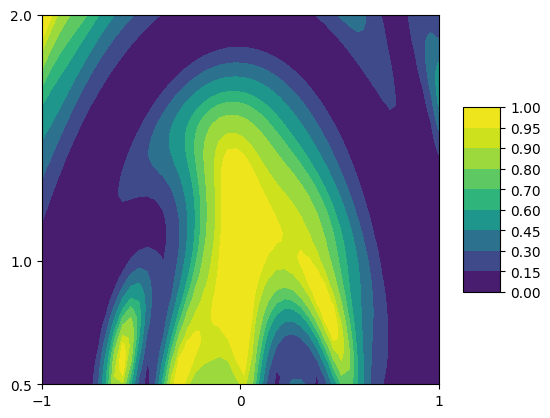

In [ ]:
#Exp BB1 : 
omega=2*np.pi*10e3
points=5
d=np.linspace(-omega,omega,points)
amp=np.linspace(omega*0.5,omega*2,points)
pairs=[[a,b] for a in d for b in amp]


cst=[]
for x in d:
    row=[]
    for y in amp:
        parameters = SimulationParams(
        T = 4e-4,
        dt = 0.1e-6,
        omega = omega,
        omega_eff=y,
        theta=np.pi,
        freq_span = 0,
        freq_span_center = x,
        sweep_time = 5*np.pi/(2*np.pi*10e3)
        )
        rap = CompositePulse(atom, parameters)
        result = rap.run(pulse="constant", phase="BB1")
        row.append(result.p1[-1])
    print(row)
    cst.append(row)

cst=np.array(cst)
ords=np.linspace(1/2,2,points)
abcs=np.linspace(-1,1,points)
x,y = np.meshgrid(abcs,ords,indexing='ij')

fig=plt.figure()

ax2=fig.add_subplot(111)
contour=ax2.contourf(x,y,cst,levels=[0, 0.15, 0.3,0.45,0.6,0.7,0.8,0.9,0.95,1],cmap='viridis')
fig.colorbar(contour,ax=ax2,shrink=0.5,aspect=5)
ax2.set_xticks([-1, 0, 1])
ax2.set_yticks([0.5,1,2])
plt.show()



c:\Users\Sami\Project\RAP\venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


[np.float64(0.3328795019875773), np.float64(0.3592702391569149), np.float64(0.383021504185732), np.float64(0.4031377454467167), np.float64(0.4193712647348857), np.float64(0.4306334208099901), np.float64(0.43645065881942), np.float64(0.4365184883852439), np.float64(0.4303546758674585), np.float64(0.41779394538506365), np.float64(0.3987865839670133), np.float64(0.3739661016402325), np.float64(0.34374280882649644), np.float64(0.3092889806911828), np.float64(0.2707760008053362), np.float64(0.23064138342898036), np.float64(0.1898488444863237), np.float64(0.15003585681985668), np.float64(0.11301568668513728), np.float64(0.0804833124306324), np.float64(0.05396167283224628), np.float64(0.03477414143717422), np.float64(0.024072107974065775), np.float64(0.022514751836217702), np.float64(0.030350763892419502), np.float64(0.047353579914415335), np.float64(0.07278557212342587), np.float64(0.10547430000743546), np.float64(0.14378860432561588), np.float64(0.18579777857040408), np.float64(0.2293198849

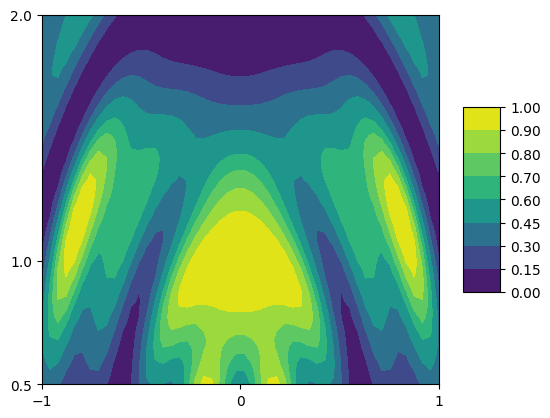

In [ ]:
#Exp CORPSE : 
omega=2*np.pi*10e3
points=5
rotation=np.pi
d=np.linspace(-omega,omega,points)
amp=np.linspace(omega*0.5,omega*2,points)
pairs=[[a,b] for a in d for b in amp]
k = np.arcsin(np.sin(rotation/2)/2)
theta1 = rotation/2 + 2*np.pi - k
theta2 = 2*np.pi - 2*k
theta3 = rotation/2-k
T1 = theta1/omega
T2 = theta2/omega
T3 = theta3/omega

cst=[]
for x in d:
    row=[]
    for y in amp:
        parameters = SimulationParams(
        T = 4e-4,
        dt = 0.1e-6,
        omega = omega,
        theta=np.pi,
        freq_span = 0,
        freq_span_center = x,
        omega_eff=y,
        sweep_time=T1+T2+T3,
        )
        rap = CompositePulse(atom, parameters)
        result = rap.run(pulse="constant", phase="BB1")
        row.append(result.p1[-1])
    print(row)
    cst.append(row)

cst=np.array(cst)

ords=np.linspace(1/2,2,points)
abcs=np.linspace(-1,1,points)
x,y = np.meshgrid(abcs,ords,indexing='ij')

fig=plt.figure()

ax2=fig.add_subplot(111)
contour=ax2.contourf(x,y,cst,levels=[0, 0.15, 0.3,0.45,0.6,0.7,0.8,0.9,1],cmap='viridis')
fig.colorbar(contour,ax=ax2,shrink=0.5,aspect=5)
ax2.set_xticks([-1, 0, 1])
ax2.set_yticks([0.5,1,2])
plt.show()



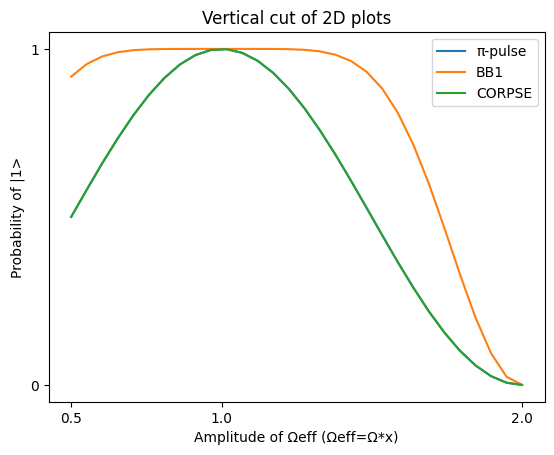

In [14]:
#Vertical cut: 
omega=2*np.pi*10e3
points=30
amp=np.linspace(omega*0.5,omega*2,points)
k = np.arcsin(np.sin(np.pi/2)/2)
theta1 = np.pi/2 + 2*np.pi - k
theta2 = 2*np.pi - 2*k
theta3 = np.pi/2-k
T1 = theta1/omega
T2 = theta2/omega
T3 = theta3/omega

Constant=[]
BB1=[]
CORPSE=[]

for y in amp:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = 0,
    omega_eff = y,
    sweep_time=np.pi/omega
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="constant")
    Constant.append(result.p1[-1])

for y in amp:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = 0,
    omega_eff = y,
    sweep_time=5*np.pi/(2*np.pi*10e3)
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="BB1")
    BB1.append(result.p1[-1])

for y in amp:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = 0,
    omega_eff = y,
    sweep_time=T1+T2+T3
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="CORPSE")
    CORPSE.append(result.p1[-1])

abcs=np.linspace(1/2,2,points)


fig,ax =plt.subplots()
ax.plot(abcs,Constant,label="π-pulse")
ax.plot(abcs,BB1,label="BB1")
ax.plot(abcs,CORPSE,label="CORPSE")
ax.set_xlabel("Amplitude of Ωeff (Ωeff=Ω*x)")
ax.set_ylabel("Probability of |1>")
ax.legend()
ax.set_title("Vertical cut of 2D plots")
ax.set_yticks([0, 1])
ax.set_xticks([0.5,1,2])
plt.show()



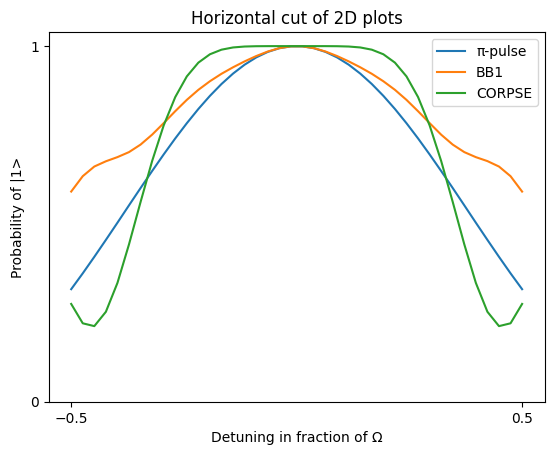

In [19]:
#Horizontal cut: 
omega=2*np.pi*10e3
points=40
d=np.linspace(-omega/2,omega/2,points)
k = np.arcsin(np.sin(np.pi/2)/2)
theta1 = np.pi/2 + 2*np.pi - k
theta2 = 2*np.pi - 2*k
theta3 = np.pi/2-k
T1 = theta1/omega
T2 = theta2/omega
T3 = theta3/omega

Constant=[]
BB1=[]
CORPSE=[]

for x in d:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = x,
    omega_eff = omega,
    sweep_time=np.pi/omega
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="constant")
    Constant.append(result.p1[-1])

for x in d:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = x,
    omega_eff = omega,
    sweep_time=5*np.pi/(2*np.pi*10e3)
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="BB1")
    BB1.append(result.p1[-1])

for x in d:
    parameters = SimulationParams(
    T = 4e-4,
    dt = 0.1e-6,
    omega = omega,
    theta=np.pi,
    freq_span = 0,
    freq_span_center = x,
    omega_eff = omega,
    sweep_time=T1+T2+T3
    )
    rap = CompositePulse(atom, parameters)
    result = rap.run(pulse="constant", phase="CORPSE")
    CORPSE.append(result.p1[-1])

abcs=np.linspace(-1/2,1/2,points)


fig,ax =plt.subplots()
ax.plot(abcs,Constant,label="π-pulse")
ax.plot(abcs,BB1,label="BB1")
ax.plot(abcs,CORPSE,label="CORPSE")
ax.set_xlabel("Detuning in fraction of Ω")
ax.set_ylabel("Probability of |1>")
ax.legend()
ax.set_title("Horizontal cut of 2D plots")
ax.set_yticks([0, 1])
ax.set_xticks([-1/2,1/2])
plt.show()

